# Task 4. Anomaly Detection Using Single-Class Classification Models

In [1]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.cm as cm
import soundfile as sf
import seaborn as sns
from scipy.io import wavfile
from scipy.signal import stft
from scipy.stats import entropy, gmean, kurtosis, skew
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline



## 1. Loading the files and creating a data frame

In [3]:
# - Durchsucht Unterordner Z01 und Z05 jeweils in deren Wav-Unterordner
pattern = os.path.join('*Datei', 'sig', 'Z*', 'Z*', 'Z*', 'Wav', '*.wav')

# Alle Dateien finden, die dem Muster entsprechen
files = glob.glob(pattern)
print(len(files), 'files', '\n', files[264])  # Print for Error-Checks


440 files 
 Seminaraufgabe_4_Datei/sig/Z01/Z01_Pos07_RC2_75k_0000/Z01_Pos07_RC2_75k_0000_1307031432/Wav/Z01_Pos07_RC2_75k_0000_1307031432_00000_14_Ch1.wav


In [4]:
data = []

# Durchläuft alle gefundenen Dateien
for fn in files:
    try:
        # fs = Abtastrate (Sampling Frequency)
        signal, fs = sf.read(fn)
    except Exception as e:
        # Print for Error
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue  # Überspringt fehlerhafte Datei

    # Extrahiert Dateinamen
    basename = os.path.basename(fn)
    parts = basename.split('_')

    # Erstellt Datensatz mit Metadaten und Signal (Keys der Aufgabenstellung entsprechend)
    entry = {
        'fn': basename,         
        'sig': signal,     
        'spec': parts[0],  
        'mID': parts[4],   
        'time': parts[5],  
        'rID': parts[6],     
        'sID': parts[8][:-4],  
        'stft': None       
    }
    
    data.append(entry)  # Fügt Datensatz zur Liste hinzu

# Erstellt DataFrame aus der Liste
df = pd.DataFrame(data)

# Zeigt die ersten 5 Einträge zur Qualitätskontrolle (Error-Checking)
print("DataFrame-Übersicht:")
print(df.head())

DataFrame-Übersicht:
                                                  fn  \
0  Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch2...   
1  Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch1...   
2  Z05_Pos09_RC2_75k_0000_1307031540_00001_14_Ch2...   
3  Z05_Pos09_RC2_75k_0000_1307031540_00001_14_Ch1...   
4  Z05_Pos08_RC2_75k_0000_1307031539_00000_14_Ch2...   

                                                 sig spec   mID        time  \
0  [0.00048828125, -0.00048828125, 0.0009765625, ...  Z05  0000  1307031540   
1  [0.0029296875, 0.00244140625, 0.00146484375, 0...  Z05  0000  1307031540   
2  [0.0009765625, 0.00048828125, 0.001953125, 0.0...  Z05  0000  1307031540   
3  [0.0029296875, 0.00244140625, 0.00146484375, 0...  Z05  0000  1307031540   
4  [0.0009765625, -0.0009765625, 0.0, 0.001464843...  Z05  0000  1307031539   

     rID  sID  stft  
0  00000  Ch2  None  
1  00000  Ch1  None  
2  00001  Ch2  None  
3  00001  Ch1  None  
4  00000  Ch2  None  


## 2. Applying STFT

In [5]:
for idx, row in df.iterrows():
    fs = 1e6  # Anpassen an reale Abtastrate
    f, t, Zxx = stft(row['sig'], 
                    fs=fs,
                    window='hann', 
                    nperseg=512,    # Fensterlänge
                    noverlap=256)   # 50% Overlap
    
    df.at[idx, 'stft'] = (f, t, np.abs(Zxx))

In [6]:
def plot_spectrogram_signal(row, nfft=2048, noverlap=1024, fmax=100000):
    signal = row['sig']

    # Setzt die Abtastrate (Samplingrate); falls nicht im DataFrame, Standardwert verwenden
    fs = row.get('fs', 1041666)  # ggf. anpassen!

    # Erstellt eine neue Abbildung für das Spektrogramm
    plt.figure(figsize=(10, 5))

    # Berechnet und plottet das Spektrogramm des Signals:
    
    Pxx, freqs, bins, im = plt.specgram(
        signal,                 # Zeitsignal
        NFFT=nfft,              # Fensterlänge für die FFT (hier 2048 Samples)
        Fs=fs,                  # Abtastrate in Hz
        noverlap=noverlap,      # Überlappung zwischen den Fenstern (hier 1024 Samples)
        scale='dB',             # Amplituden werden in Dezibel dargestellt
        cmap='magma'          # Farbskala für die Darstellung (gelb, grün, türkis)
    )

    plt.title(f"Spektrogramm {row['spec']} - {row['sID']}")     # Titel 
    plt.ylabel('Frequenz [Hz]')                                 # y-Achse
    plt.xlabel('Zeit [s]')                                      # x-Achse
    plt.ylim(0, fmax)                                           # Relevanten Bereich zeigen (100 kHz)

    # Fügt eine Farbskala hinzu, die die Amplitude in dB anzeigt
    plt.colorbar(label='Amplitude [dB]')
    
    plt.tight_layout()
    plt.show()

## 3. Feature extraction

In [7]:
def analyze_stft(stft):
    magnitude = np.abs(stft[2])
    mag_mean = np.mean(magnitude, axis=1)  # magnitude averaged by time
    spectral_mean = np.sum(stft[0] * mag_mean) / np.sum(mag_mean) # average frequency, weighted by magnitude
    spectral_variance = np.sum(((stft[0] - spectral_mean) ** 2) * mag_mean) / np.sum(mag_mean) #distance of each frequency bin from the mean
    upper_half = mag_mean[len(stft[0])//2:]
    prob_dist = upper_half / np.sum(upper_half)
    entropy_upper = entropy(prob_dist) # how irregular the upper part of the spectrum is
    flatness = gmean(upper_half + 1e-8) / np.mean(upper_half) # how much noise there is
    cumulative_energy = np.cumsum(mag_mean)
    rolloff_idx = np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])
    rolloff_freq = stft[0][rolloff_idx]  # 85% of energy is below this frequency
    kurt_upper = kurtosis(upper_half) # reflects spikiness or asymmetry in the upper band
    
    return spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper


def analyze_signal(sig):
    signal_mean = np.mean(sig)
    signal_variance = np.var(sig)
    signal_skewness = skew(sig)
    signal_kurtosis = kurtosis(sig)  # fourth moment
    signal_rms = np.sqrt(np.mean(sig**2))
    signal_peak = np.max(np.abs(sig))  # peak amplitude
    return signal_mean, signal_variance, signal_skewness, signal_rms, signal_peak, signal_kurtosis



In [8]:
featureslist = [
    'sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis',
    'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis'
]

In [9]:
for idx, row in df.iterrows():
    sig = row['sig']
    sig_mean, sig_var, sig_skew, sig_rms, sig_peak, sig_kurtosis = analyze_signal(sig)
    df.at[idx, 'sig_mean'] = sig_mean
    df.at[idx, 'sig_var'] = sig_var
    df.at[idx, 'sig_skew'] = sig_skew
    df.at[idx, 'sig_rms'] = sig_rms
    df.at[idx, 'sig_peak'] = sig_peak
    df.at[idx, 'sig_kurtosis'] = sig_kurtosis
    
    stft = row['stft']
    spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper = analyze_stft(stft)
    df.at[idx, 'spec_mean'] = spectral_mean
    df.at[idx, 'spec_var'] = spectral_variance
    df.at[idx, 'spec_entropy_up'] = entropy_upper
    df.at[idx, 'spec_flatness'] = flatness
    df.at[idx, 'spec_rolloff_freq'] = rolloff_freq
    df.at[idx, 'spec_kurtosis'] = kurt_upper


    

In [10]:
# Ensure all feature columns are numeric in original df before splitting
for feature in featureslist:
    df[feature] = pd.to_numeric(df[feature], errors='coerce')

df.head(3)



,fn,sig,spec,mID,time,rID,sID,stft,sig_mean,sig_var,sig_skew,sig_rms,sig_peak,sig_kurtosis,spec_mean,spec_var,spec_entropy_up,spec_flatness,spec_rolloff_freq,spec_kurtosis
0,Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch2...,"[0.00048828125, -0.00048828125, 0.0009765625, ...",Z05,0000,1307031540,00000,Ch2,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",0.000501,0.000599,0.106331,0.024475,0.380035,44.140591,79247.110002,1.446442e+10,4.570369,0.817315,201171.875,34.598637
1,Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch1...,"[0.0029296875, 0.00244140625, 0.00146484375, 0...",Z05,0000,1307031540,00000,Ch1,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",0.001037,0.000353,-0.368753,0.018824,0.310669,37.879398,78711.348966,1.556353e+10,4.689152,0.883210,218750.000,27.328684
2,Z05_Pos09_RC2_75k_0000_1307031540_00001_14_Ch2...,"[0.0009765625, 0.00048828125, 0.001953125, 0.0...",Z05,0000,1307031540,00001,Ch2,"([0.0, 1953.125, 3906.25, 5859.375, 7812.5, 97...",0.000932,0.000609,0.115046,0.024694,0.384430,44.362172,70730.244652,1.271795e+10,4.586447,0.855784,148437.500,50.755008


## 4. Separating the Channels

In [11]:
df['sID'] = df['sID'].astype(str).str.strip()

df_ch1 = df[df['sID'] == 'Ch1'].copy()
df_ch2 = df[df['sID'] == 'Ch2'].copy()

df_ch1.info() 
df_ch2.info()


print(f"Anzahl der Beispiele in Kanal 1 (Ch1): {df_ch1.shape[0]}")
print(f"Anzahl der Beispiele in Kanal 2 (Ch2): {df_ch2.shape[0]}")

print("\nVerteilung der Spezifikation (spec) in Ch1:")
print(df_ch1['spec'].value_counts())

print("\nVerteilung der Spezifikation (spec) in Ch2:")
print(df_ch2['spec'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 1 to 439
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fn                 220 non-null    object 
 1   sig                220 non-null    object 
 2   spec               220 non-null    object 
 3   mID                220 non-null    object 
 4   time               220 non-null    object 
 5   rID                220 non-null    object 
 6   sID                220 non-null    object 
 7   stft               220 non-null    object 
 8   sig_mean           220 non-null    float64
 9   sig_var            220 non-null    float64
 10  sig_skew           220 non-null    float64
 11  sig_rms            220 non-null    float64
 12  sig_peak           220 non-null    float64
 13  sig_kurtosis       220 non-null    float64
 14  spec_mean          220 non-null    float64
 15  spec_var           220 non-null    float64
 16  spec_entropy_up    220 non-null

## 5. Leave P Group(s) Out cross-validation strategy - **1st Channel**

In [12]:
# First: assign label = 0 for all normal (Z01–Z04), and 1 for anomalies (Z05)
df_ch1['label'] = df_ch1['spec'].apply(lambda x: 1 if x == 'Z05' else 0)

# Define a function to filter dataset by group membership
def filter_groups(df, train_groups, test_groups):
    train = df[df['spec'].isin(train_groups)].copy()
    test  = df[df['spec'].isin(test_groups)].copy()
    return train.reset_index(drop=True), test.reset_index(drop=True)

# Create splits as defined
splits = [
    (['Z01', 'Z02', 'Z03'], ['Z04', 'Z05']),
    (['Z01', 'Z02', 'Z04'], ['Z03', 'Z05']),
    (['Z01', 'Z03', 'Z04'], ['Z02', 'Z05']),
    (['Z02', 'Z03', 'Z04'], ['Z01', 'Z05']),
]

group_splits_ch1 = []

# Process each split
# labels: first element in array - amount of Z05 data, second element - amount of Z01-Z04
for idx, (train_groups, test_groups) in enumerate(splits, 1):
    train_df, test_df = filter_groups(df_ch1, train_groups, test_groups)

    print(f"\nSplit {idx} (Ch1)")
    print(f"Train groups: {train_groups}")
    print(f"Test groups: {test_groups}")
    print(f"Train size: {train_df.shape[0]} (labels: {np.bincount(train_df['label'])})")
    print(f"Test  size: {test_df.shape[0]} (labels: {np.bincount(test_df['label'])})")

    group_splits_ch1.append((train_df, test_df))



Split 1 (Ch1)
Train groups: ['Z01', 'Z02', 'Z03']
Test groups: ['Z04', 'Z05']
Train size: 140 (labels: [140])
Test  size: 80 (labels: [60 20])

Split 2 (Ch1)
Train groups: ['Z01', 'Z02', 'Z04']
Test groups: ['Z03', 'Z05']
Train size: 180 (labels: [180])
Test  size: 40 (labels: [20 20])

Split 3 (Ch1)
Train groups: ['Z01', 'Z03', 'Z04']
Test groups: ['Z02', 'Z05']
Train size: 180 (labels: [180])
Test  size: 40 (labels: [20 20])

Split 4 (Ch1)
Train groups: ['Z02', 'Z03', 'Z04']
Test groups: ['Z01', 'Z05']
Train size: 100 (labels: [100])
Test  size: 120 (labels: [100  20])


## Leave P Group(s) Out cross-validation strategy - **2nd Channel**

In [13]:
# First: assign label = 0 for all normal (Z01–Z04), and 1 for anomalies (Z05)
df_ch2['label'] = df_ch2['spec'].apply(lambda x: 1 if x == 'Z05' else 0)

# Define a function to filter dataset by group membership
def filter_groups(df, train_groups, test_groups):
    train = df[df['spec'].isin(train_groups)].copy()
    test  = df[df['spec'].isin(test_groups)].copy()
    return train.reset_index(drop=True), test.reset_index(drop=True)

# Create splits as defined
splits = [
    (['Z01', 'Z02', 'Z03'], ['Z04', 'Z05']),
    (['Z01', 'Z02', 'Z04'], ['Z03', 'Z05']),
    (['Z01', 'Z03', 'Z04'], ['Z02', 'Z05']),
    (['Z02', 'Z03', 'Z04'], ['Z01', 'Z05']),
]

group_splits_ch2 = []

# Process each split
# labels: first element in array - amount of Z05 data, second element - amount of Z01-Z04
for idx, (train_groups, test_groups) in enumerate(splits, 1):
    train_df, test_df = filter_groups(df_ch2, train_groups, test_groups)

    print(f"\nSplit {idx} (Ch2)")
    print(f"Train groups: {train_groups}")
    print(f"Test groups: {test_groups}")
    print(f"Train size: {train_df.shape[0]} (labels: {np.bincount(train_df['label'])})")
    print(f"Test  size: {test_df.shape[0]} (labels: {np.bincount(test_df['label'])})")

    group_splits_ch2.append((train_df, test_df))


Split 1 (Ch2)
Train groups: ['Z01', 'Z02', 'Z03']
Test groups: ['Z04', 'Z05']
Train size: 140 (labels: [140])
Test  size: 80 (labels: [60 20])

Split 2 (Ch2)
Train groups: ['Z01', 'Z02', 'Z04']
Test groups: ['Z03', 'Z05']
Train size: 180 (labels: [180])
Test  size: 40 (labels: [20 20])

Split 3 (Ch2)
Train groups: ['Z01', 'Z03', 'Z04']
Test groups: ['Z02', 'Z05']
Train size: 180 (labels: [180])
Test  size: 40 (labels: [20 20])

Split 4 (Ch2)
Train groups: ['Z02', 'Z03', 'Z04']
Test groups: ['Z01', 'Z05']
Train size: 100 (labels: [100])
Test  size: 120 (labels: [100  20])


## 6. One-Class Classifier Using SVM

One-Class SVM — Training on each split (Ch1)

Split 1
X_train shape: (140, 12)


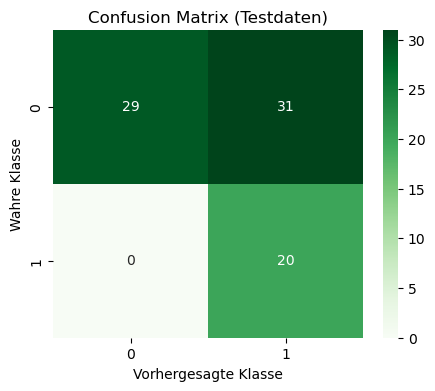

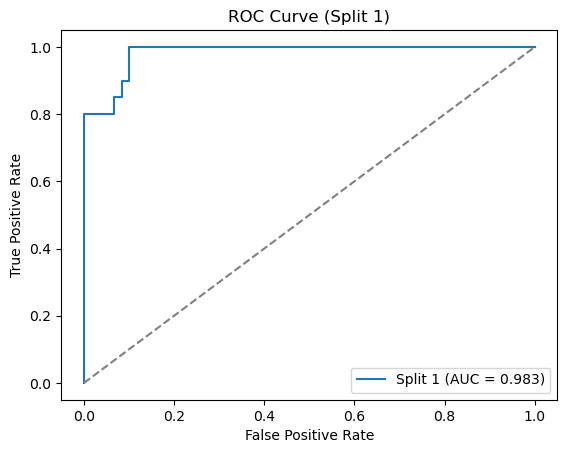

              precision    recall  f1-score   support

           0      1.000     0.483     0.652        60
           1      0.392     1.000     0.563        20

    accuracy                          0.613        80
   macro avg      0.696     0.742     0.608        80
weighted avg      0.848     0.613     0.630        80

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 0.483
Accuracy: 0.613
Balanced Accuracy (BAR): 0.742

Split 2
X_train shape: (180, 12)


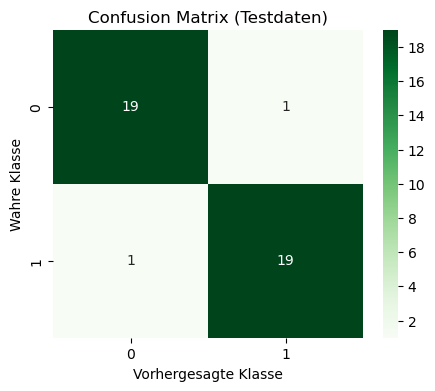

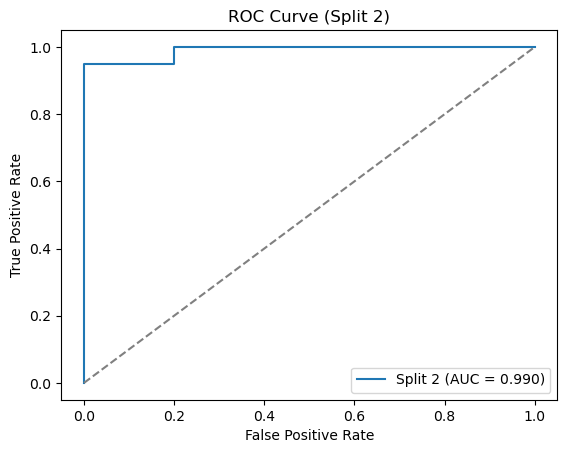

              precision    recall  f1-score   support

           0      0.950     0.950     0.950        20
           1      0.950     0.950     0.950        20

    accuracy                          0.950        40
   macro avg      0.950     0.950     0.950        40
weighted avg      0.950     0.950     0.950        40

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 0.950
Accuracy: 0.950
Balanced Accuracy (BAR): 0.950

Split 3
X_train shape: (180, 12)


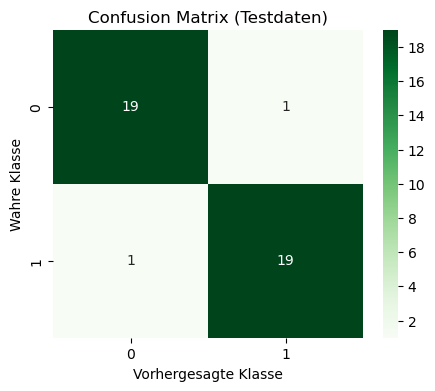

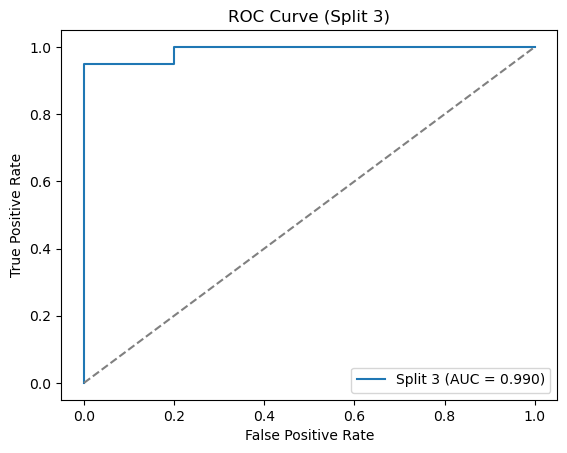

              precision    recall  f1-score   support

           0      0.950     0.950     0.950        20
           1      0.950     0.950     0.950        20

    accuracy                          0.950        40
   macro avg      0.950     0.950     0.950        40
weighted avg      0.950     0.950     0.950        40

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 0.950
Accuracy: 0.950
Balanced Accuracy (BAR): 0.950

Split 4
X_train shape: (100, 12)


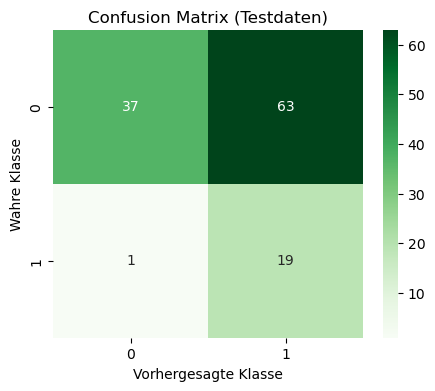

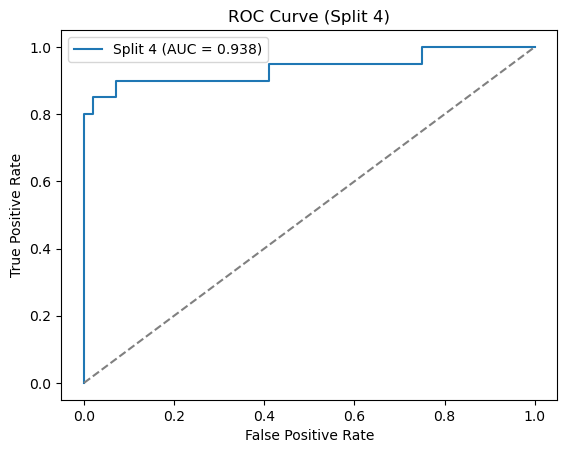

              precision    recall  f1-score   support

           0      0.974     0.370     0.536       100
           1      0.232     0.950     0.373        20

    accuracy                          0.467       120
   macro avg      0.603     0.660     0.454       120
weighted avg      0.850     0.467     0.509       120

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 0.370
Accuracy: 0.467
Balanced Accuracy (BAR): 0.660


In [14]:
preprocessor = make_pipeline(
    RobustScaler(),
    PCA(n_components=0.95))

print("One-Class SVM — Training on each split (Ch1)")

for idx, (train_df, test_df) in enumerate(group_splits_ch1, 1):
    print(f"\nSplit {idx}")

# Grouping the sets  
    X_train = train_df[train_df['label'] == 0][featureslist]
    X_test = test_df[featureslist].select_dtypes(include=[float, int])
    y_test = test_df['label']

    print(f"X_train shape: {X_train.shape}")
    #print(f"X_train columns: {X_train.columns.tolist()}")
    #print(X_train.head())

# Scaling and PCA
    X_train_pca = preprocessor.fit_transform(X_train)
    X_test_pca = preprocessor.transform(X_test)

# Training the model    
    model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
    model.fit(X_train_pca)

# Testing the model    
    y_pred = model.predict(X_test_pca)
    y_pred_binary = np.where(y_pred == 1, 0, 1)


# Visualizing the confusion matrix
    conf = confusion_matrix(y_test, y_pred_binary)
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix (Testdaten)')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Wahre Klasse')
    plt.show()

    
# Getting decision function scores for ROC curve
    scores_test = -model.decision_function(X_test_pca)

# Visualizing the ROC curve from the decision function
    fpr, tpr, thresholds = roc_curve(y_test, scores_test)
    roc_auc = roc_auc_score(y_test, scores_test)

    plt.figure()
    plt.plot(fpr, tpr, label=f"Split {idx} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Split {idx})")
    plt.legend()
    plt.show()

# Printing precision, recall, f1-score, support, sensitivity, specificity, and (balanced) accuracy
    print(classification_report(y_test, y_pred_binary, digits=3))
    if conf.shape == (2,2):
        tn, fp, fn, tp = conf.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy    = (tp + tn) / (tp + tn + fp + fn)
        balanced_accuracy = (sensitivity + specificity) / 2

        print(f"Sensitivity (Recall for normal class): {sensitivity:.3f}")
        print(f"Specificity (True negative rate): {specificity:.3f}")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Balanced Accuracy (BAR): {balanced_accuracy:.3f}")
    else:
        print("Cannot compute metrics: confusion matrix is not 2x2.")


One-Class SVM — Training on each split (Ch2)

Split 1
X_train shape: (140, 12)


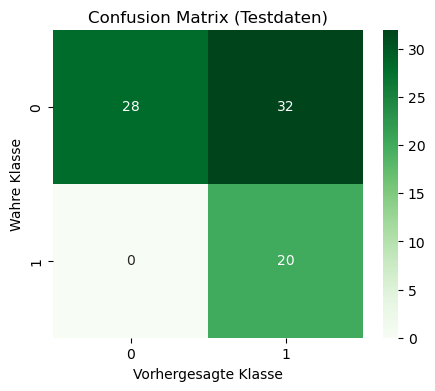

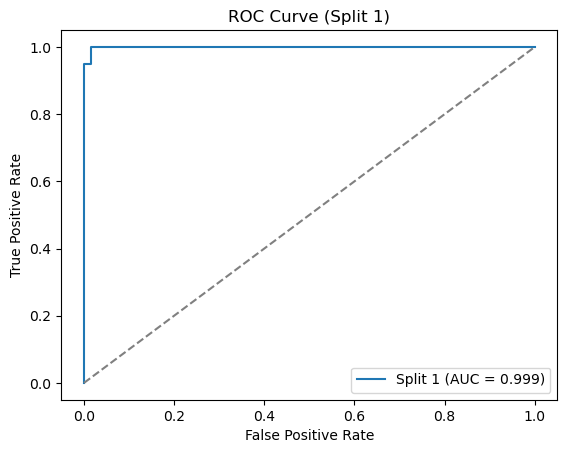

              precision    recall  f1-score   support

           0      1.000     0.467     0.636        60
           1      0.385     1.000     0.556        20

    accuracy                          0.600        80
   macro avg      0.692     0.733     0.596        80
weighted avg      0.846     0.600     0.616        80

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 0.467
Accuracy: 0.600
Balanced Accuracy (BAR): 0.733

Split 2
X_train shape: (180, 12)


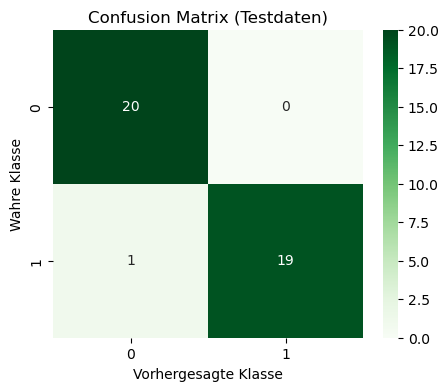

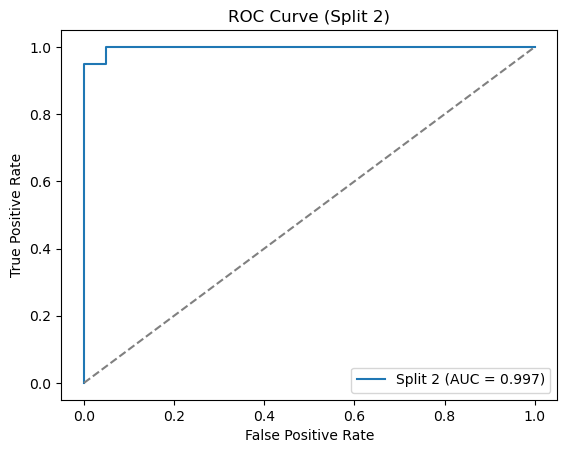

              precision    recall  f1-score   support

           0      0.952     1.000     0.976        20
           1      1.000     0.950     0.974        20

    accuracy                          0.975        40
   macro avg      0.976     0.975     0.975        40
weighted avg      0.976     0.975     0.975        40

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 1.000
Accuracy: 0.975
Balanced Accuracy (BAR): 0.975

Split 3
X_train shape: (180, 12)


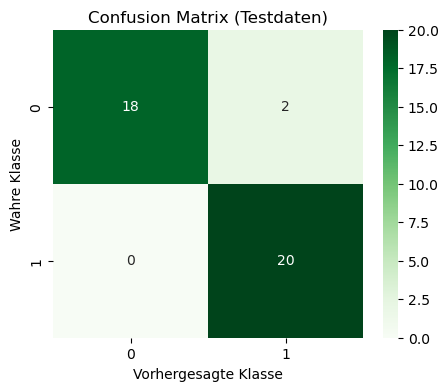

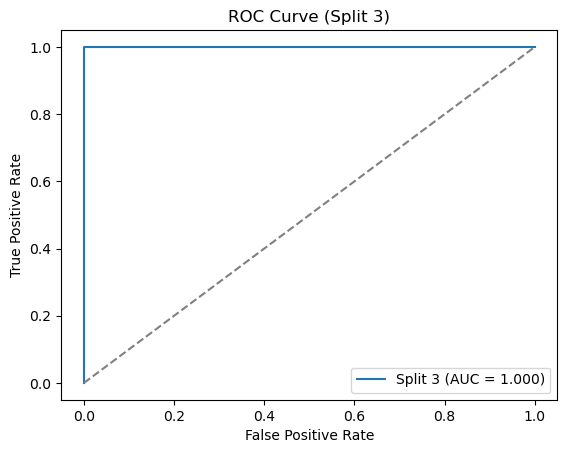

              precision    recall  f1-score   support

           0      1.000     0.900     0.947        20
           1      0.909     1.000     0.952        20

    accuracy                          0.950        40
   macro avg      0.955     0.950     0.950        40
weighted avg      0.955     0.950     0.950        40

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 0.900
Accuracy: 0.950
Balanced Accuracy (BAR): 0.950

Split 4
X_train shape: (100, 12)


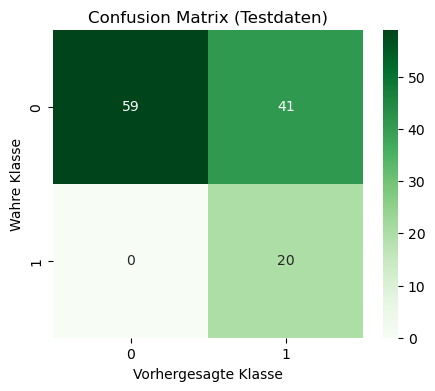

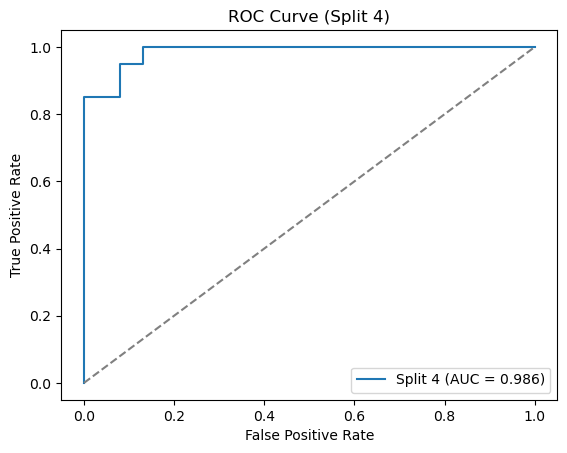

              precision    recall  f1-score   support

           0      1.000     0.590     0.742       100
           1      0.328     1.000     0.494        20

    accuracy                          0.658       120
   macro avg      0.664     0.795     0.618       120
weighted avg      0.888     0.658     0.701       120

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 0.590
Accuracy: 0.658
Balanced Accuracy (BAR): 0.795


In [15]:
print("One-Class SVM — Training on each split (Ch2)")

for idx, (train_df, test_df) in enumerate(group_splits_ch2, 1):
    print(f"\nSplit {idx}")

# Grouping the sets  
    X_train = train_df[train_df['label'] == 0][featureslist]
    X_test = test_df[featureslist].select_dtypes(include=[float, int])
    y_test = test_df['label']

    print(f"X_train shape: {X_train.shape}")
    #print(f"X_train columns: {X_train.columns.tolist()}")
    #print(X_train.head())


# Scaling and PCA
    X_train_pca = preprocessor.fit_transform(X_train)
    X_test_pca = preprocessor.transform(X_test)


# Training the model    
    model = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
    model.fit(X_train_pca)

# Testing the model    
    y_pred = model.predict(X_test_pca)
    y_pred_binary = np.where(y_pred == 1, 0, 1)


# Visualizing the confusion matrix
    conf = confusion_matrix(y_test, y_pred_binary)
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix (Testdaten)')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Wahre Klasse')
    plt.show()

    
# Getting decision function scores for ROC curve
    scores_test = -model.decision_function(X_test_pca)

# Visualizing the ROC curve from the decision function
    fpr, tpr, thresholds = roc_curve(y_test, scores_test)
    roc_auc = roc_auc_score(y_test, scores_test)

    plt.figure()
    plt.plot(fpr, tpr, label=f"Split {idx} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Split {idx})")
    plt.legend()
    plt.show()

# Printing precision, recall, f1-score, support, sensitivity, specificity, and (balanced) accuracy
    print(classification_report(y_test, y_pred_binary, digits=3))
    if conf.shape == (2,2):
        tn, fp, fn, tp = conf.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy    = (tp + tn) / (tp + tn + fp + fn)
        balanced_accuracy = (sensitivity + specificity) / 2

        print(f"Sensitivity (Recall for normal class): {sensitivity:.3f}")
        print(f"Specificity (True negative rate): {specificity:.3f}")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Balanced Accuracy (BAR): {balanced_accuracy:.3f}")
    else:
        print("Cannot compute metrics: confusion matrix is not 2x2.")


## 7. One-Class Classifier Using Isolation Forest

Isolation Forest — Training on each split (Ch1)

Split 1
X_train shape: (140, 12)


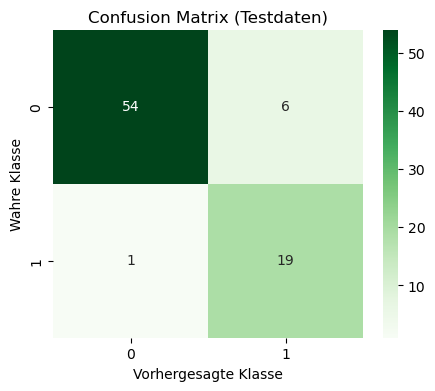

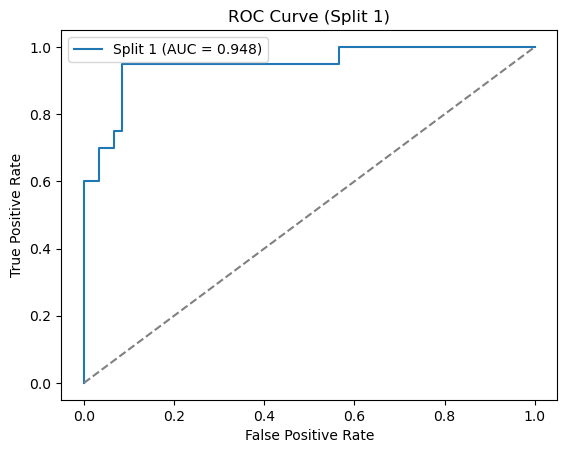

              precision    recall  f1-score   support

           0      0.982     0.900     0.939        60
           1      0.760     0.950     0.844        20

    accuracy                          0.912        80
   macro avg      0.871     0.925     0.892        80
weighted avg      0.926     0.912     0.915        80

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 0.900
Accuracy: 0.912
Balanced Accuracy (BAR): 0.925

Split 2
X_train shape: (180, 12)


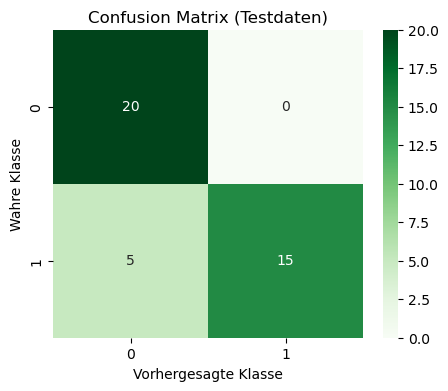

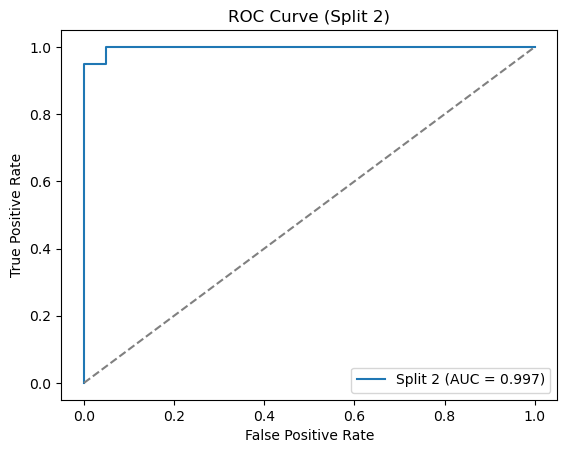

              precision    recall  f1-score   support

           0      0.800     1.000     0.889        20
           1      1.000     0.750     0.857        20

    accuracy                          0.875        40
   macro avg      0.900     0.875     0.873        40
weighted avg      0.900     0.875     0.873        40

Sensitivity (Recall for normal class): 0.750
Specificity (True negative rate): 1.000
Accuracy: 0.875
Balanced Accuracy (BAR): 0.875

Split 3
X_train shape: (180, 12)


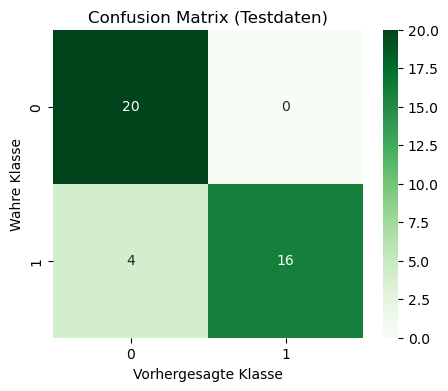

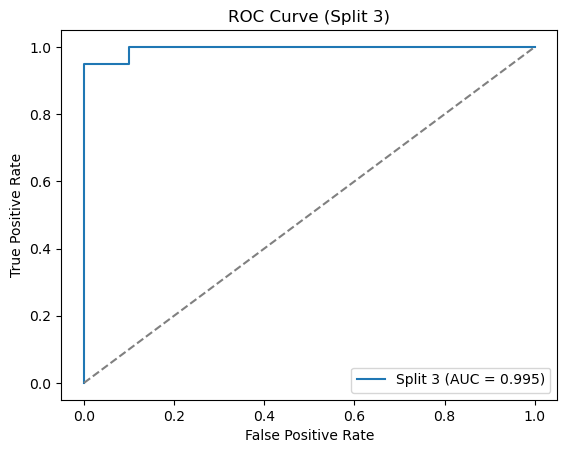

              precision    recall  f1-score   support

           0      0.833     1.000     0.909        20
           1      1.000     0.800     0.889        20

    accuracy                          0.900        40
   macro avg      0.917     0.900     0.899        40
weighted avg      0.917     0.900     0.899        40

Sensitivity (Recall for normal class): 0.800
Specificity (True negative rate): 1.000
Accuracy: 0.900
Balanced Accuracy (BAR): 0.900

Split 4
X_train shape: (100, 12)


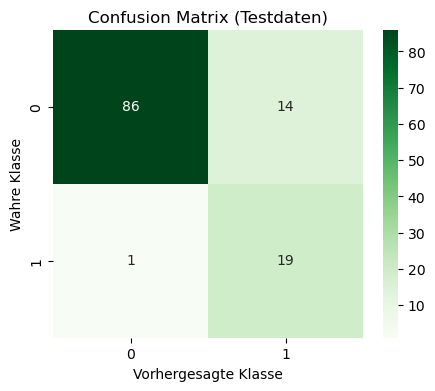

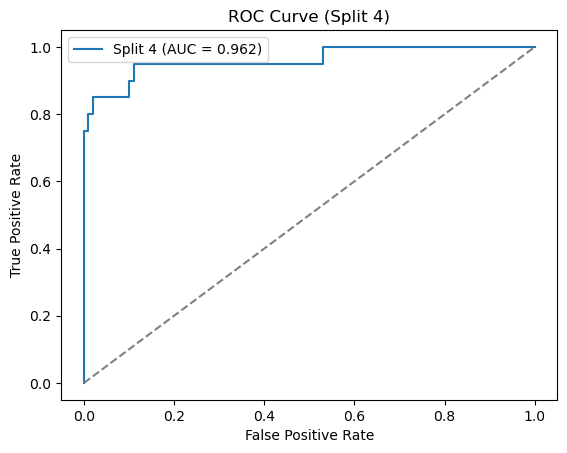

              precision    recall  f1-score   support

           0      0.989     0.860     0.920       100
           1      0.576     0.950     0.717        20

    accuracy                          0.875       120
   macro avg      0.782     0.905     0.818       120
weighted avg      0.920     0.875     0.886       120

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 0.860
Accuracy: 0.875
Balanced Accuracy (BAR): 0.905


In [16]:
from sklearn.ensemble import IsolationForest

print("Isolation Forest — Training on each split (Ch1)")

for idx, (train_df, test_df) in enumerate(group_splits_ch1, 1):
    print(f"\nSplit {idx}")

# Grouping the sets  
    X_train = train_df[train_df['label'] == 0][featureslist]
    X_test = test_df[featureslist].select_dtypes(include=[float, int])
    y_test = test_df['label']

    print(f"X_train shape: {X_train.shape}")
    #print(f"X_train columns: {X_train.columns.tolist()}")
    #print(X_train.head())

# Scaling and PCA
    X_train_pca = preprocessor.fit_transform(X_train)
    X_test_pca = preprocessor.transform(X_test)

# Training the model    
    model = IsolationForest(n_estimators=256, 
                            max_samples=100, 
                            contamination=0.01, 
                            max_features=0.8,
                            random_state=42)
    model.fit(X_train_pca)

# Testing the model    
    y_pred = model.predict(X_test_pca)
    y_pred_binary = np.where(y_pred == 1, 0, 1)

# Visualizing the confusion matrix
    conf = confusion_matrix(y_test, y_pred_binary)
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix (Testdaten)')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Wahre Klasse')
    plt.show()

    
# Getting decision function scores for ROC curve
    scores_test = -model.decision_function(X_test_pca)

# Visualizing the ROC curve from the decision function
    fpr, tpr, thresholds = roc_curve(y_test, scores_test)
    roc_auc = roc_auc_score(y_test, scores_test)

    plt.figure()
    plt.plot(fpr, tpr, label=f"Split {idx} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Split {idx})")
    plt.legend()
    plt.show()

# Printing precision, recall, f1-score, support, sensitivity, specificity, and (balanced) accuracy
    print(classification_report(y_test, y_pred_binary, digits=3))
    if conf.shape == (2,2):
        tn, fp, fn, tp = conf.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy    = (tp + tn) / (tp + tn + fp + fn)
        balanced_accuracy = (sensitivity + specificity) / 2

        print(f"Sensitivity (Recall for normal class): {sensitivity:.3f}")
        print(f"Specificity (True negative rate): {specificity:.3f}")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Balanced Accuracy (BAR): {balanced_accuracy:.3f}")
    else:
        print("Cannot compute metrics: confusion matrix is not 2x2.")




Isolation Forest — Training on each split (Ch2)

Split 1
X_train shape: (140, 12)


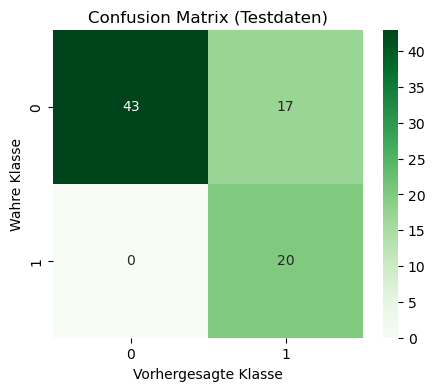

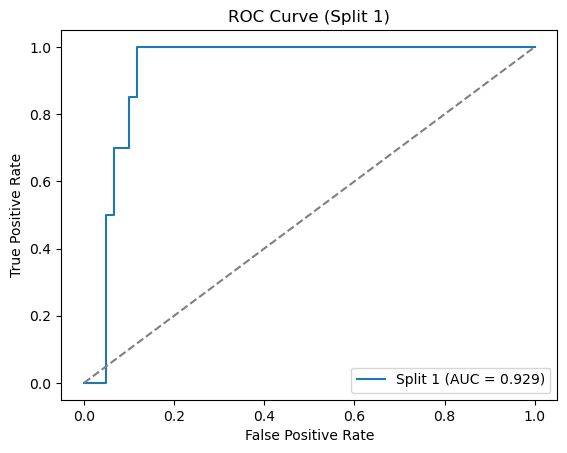

              precision    recall  f1-score   support

           0      1.000     0.717     0.835        60
           1      0.541     1.000     0.702        20

    accuracy                          0.787        80
   macro avg      0.770     0.858     0.768        80
weighted avg      0.885     0.787     0.802        80

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 0.717
Accuracy: 0.787
Balanced Accuracy (BAR): 0.858

Split 2
X_train shape: (180, 12)


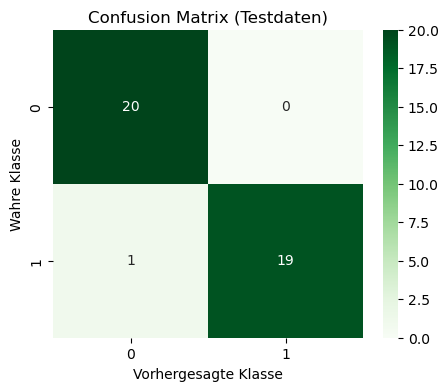

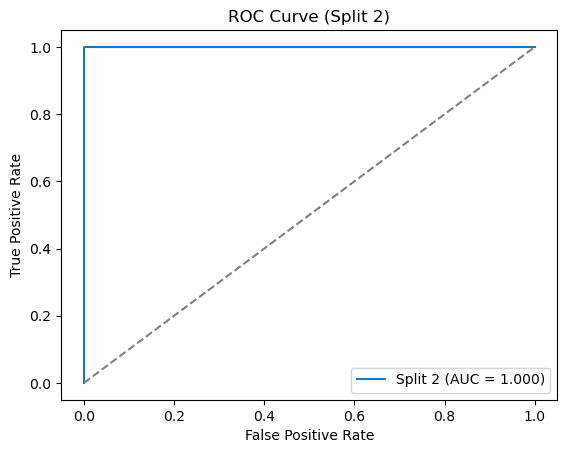

              precision    recall  f1-score   support

           0      0.952     1.000     0.976        20
           1      1.000     0.950     0.974        20

    accuracy                          0.975        40
   macro avg      0.976     0.975     0.975        40
weighted avg      0.976     0.975     0.975        40

Sensitivity (Recall for normal class): 0.950
Specificity (True negative rate): 1.000
Accuracy: 0.975
Balanced Accuracy (BAR): 0.975

Split 3
X_train shape: (180, 12)


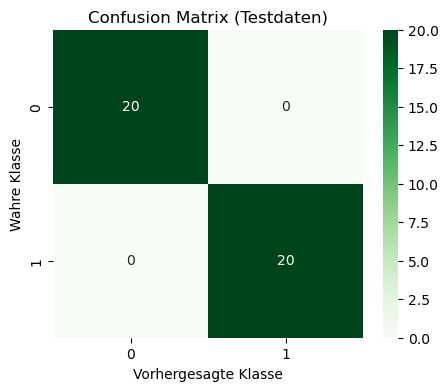

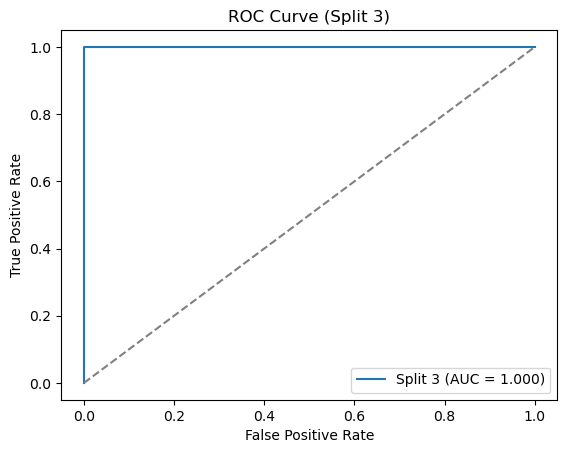

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        20
           1      1.000     1.000     1.000        20

    accuracy                          1.000        40
   macro avg      1.000     1.000     1.000        40
weighted avg      1.000     1.000     1.000        40

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 1.000
Accuracy: 1.000
Balanced Accuracy (BAR): 1.000

Split 4
X_train shape: (100, 12)


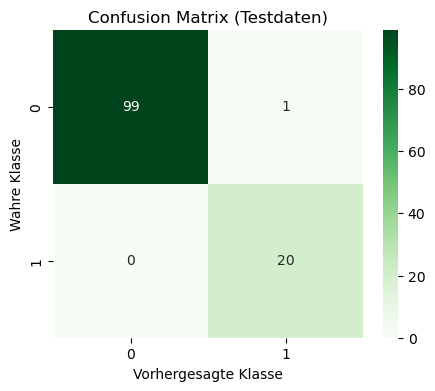

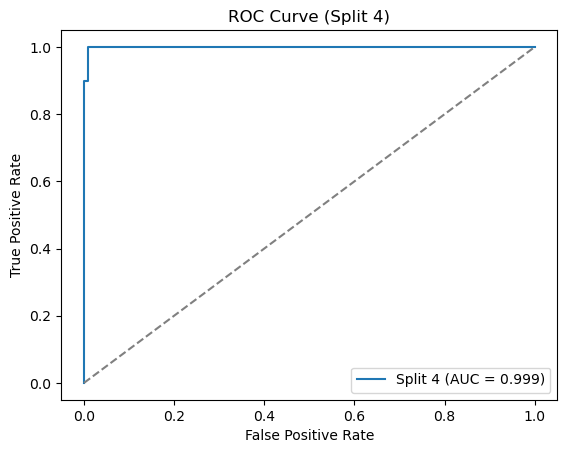

              precision    recall  f1-score   support

           0      1.000     0.990     0.995       100
           1      0.952     1.000     0.976        20

    accuracy                          0.992       120
   macro avg      0.976     0.995     0.985       120
weighted avg      0.992     0.992     0.992       120

Sensitivity (Recall for normal class): 1.000
Specificity (True negative rate): 0.990
Accuracy: 0.992
Balanced Accuracy (BAR): 0.995


In [17]:
print("Isolation Forest — Training on each split (Ch2)")

for idx, (train_df, test_df) in enumerate(group_splits_ch2, 1):
    print(f"\nSplit {idx}")

# Grouping the sets  
    X_train = train_df[train_df['label'] == 0][featureslist]
    X_test = test_df[featureslist].select_dtypes(include=[float, int])
    y_test = test_df['label']

    print(f"X_train shape: {X_train.shape}")
    #print(f"X_train columns: {X_train.columns.tolist()}")
    #print(X_train.head())

# Scaling and PCA
    X_train_pca = preprocessor.fit_transform(X_train)
    X_test_pca = preprocessor.transform(X_test)

# Training the model    
    model = IsolationForest(n_estimators=256, 
                            max_samples=100, 
                            contamination=0.01, 
                            max_features=0.8,
                            random_state=42)
    model.fit(X_train_pca)

# Testing the model    
    y_pred = model.predict(X_test_pca)
    y_pred_binary = np.where(y_pred == 1, 0, 1)

# Visualizing the confusion matrix
    conf = confusion_matrix(y_test, y_pred_binary)
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix (Testdaten)')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Wahre Klasse')
    plt.show()

    
# Getting decision function scores for ROC curve
    scores_test = -model.decision_function(X_test_pca)

# Visualizing the ROC curve from the decision function
    fpr, tpr, thresholds = roc_curve(y_test, scores_test)
    roc_auc = roc_auc_score(y_test, scores_test)

    plt.figure()
    plt.plot(fpr, tpr, label=f"Split {idx} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Split {idx})")
    plt.legend()
    plt.show()

# Printing precision, recall, f1-score, support, sensitivity, specificity, and (balanced) accuracy
    print(classification_report(y_test, y_pred_binary, digits=3))
    if conf.shape == (2,2):
        tn, fp, fn, tp = conf.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        accuracy    = (tp + tn) / (tp + tn + fp + fn)
        balanced_accuracy = (sensitivity + specificity) / 2

        print(f"Sensitivity (Recall for normal class): {sensitivity:.3f}")
        print(f"Specificity (True negative rate): {specificity:.3f}")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Balanced Accuracy (BAR): {balanced_accuracy:.3f}")
    else:
        print("Cannot compute metrics: confusion matrix is not 2x2.")




## 8. Interpretation

<ul> 
    <li> For any given model, splits 2 (train: Z01, Z02, Z04, test: Z03, Z05) and 3 (train: Z01, Z03, Z04, test: Z02, Z05) provided better results, which can be explained by a higher number of training samples. Both splits contained Z01 and Z04 in the training data, which accounted for 160 samples out of 220 for each channel.</li>
    <li> For the other two splits, both models initially demonstrated a very high number of false positives, which could not be corrected for SVM.</li>
    <li> In the Isolation Forest model, this issue was later resolved by setting the "contamination" parameter to 0.01 - meaning that the model was informed that the amount of anomalies in the training sets will not exceed 1%. This allowed the model to spot outliers that were in the test set more efficiently.</li>
    <li> On average, the Channel 2 samples allowed for slightly better results
</ul>